In [ ]:
import os
import matplotlib.pyplot as plt
import random

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

import numpy as np

import torch.nn as nn
import torch.nn.functional as F

import torchvision.models as models

# **Phase 1**

In [ ]:
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/DeepLearningProject/data/train/task2train540p /content/

In [ ]:
train_path = "/content/task2train540p"

classes = os.listdir(train_path)

print("Classes Found:")
print(classes)
print("Number of Classes:", len(classes))

Classes Found:
['side-road-left', 'right-hand-curve', 'left-hand-curve', 'gap-in-median']
Number of Classes: 4


In [ ]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(train_path, cls)
    images = os.listdir(class_path)
    class_counts[cls] = len(images)

print("Image count per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Image count per class:
side-road-left: 250
right-hand-curve: 250
left-hand-curve: 250
gap-in-median: 250


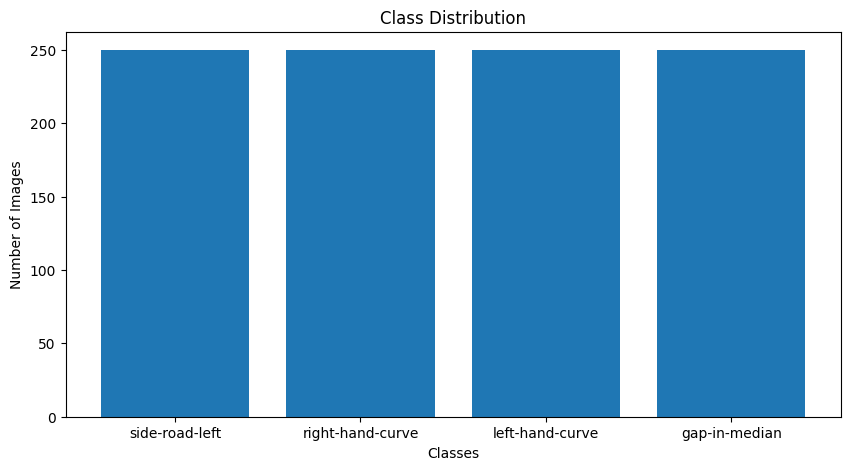

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

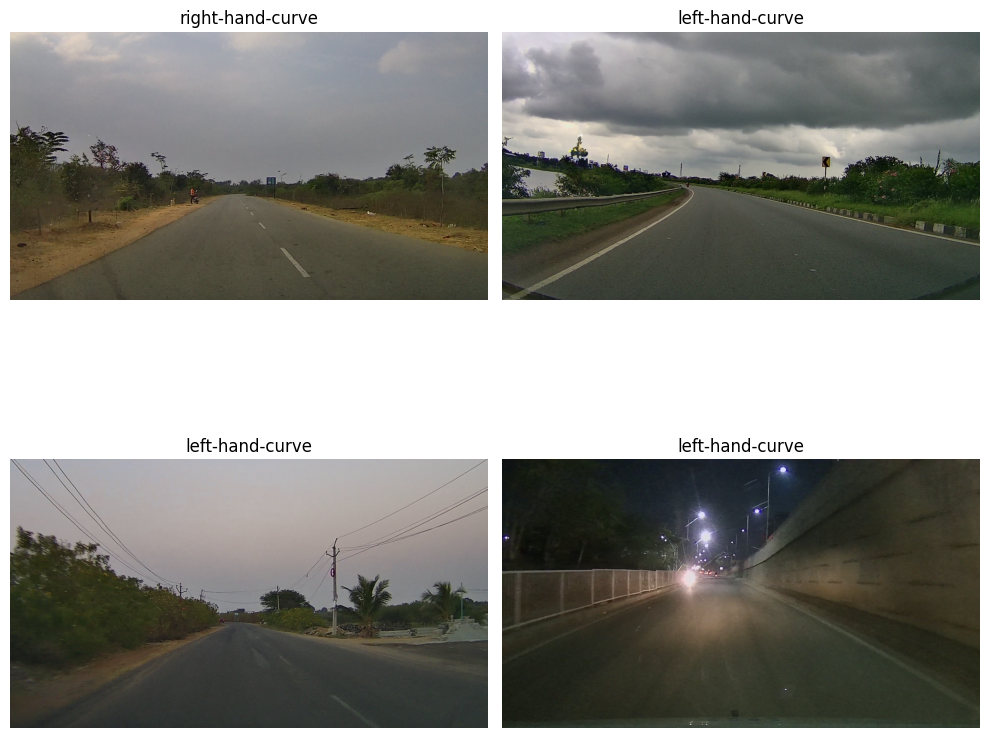

In [ ]:
plt.figure(figsize=(10,10))

for i in range(4):
    random_class = random.choice(classes)
    class_path = os.path.join(train_path, random_class)
    random_image = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, random_image)
    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(random_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Phase 2**

In [ ]:
mean = [0.3606, 0.3610, 0.3389]
std  = [0.1820, 0.1793, 0.2000]

In [ ]:
IMAGE_SIZE = 128

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,
                         std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,
                         std=std)
])


In [ ]:
train_path = "/content/task2train540p"

full_dataset = datasets.ImageFolder(root=train_path)

print("Total Images:", len(full_dataset))
print("Classes:", full_dataset.classes)


Total Images: 1000
Classes: ['gap-in-median', 'left-hand-curve', 'right-hand-curve', 'side-road-left']


In [ ]:
num_classes = len(full_dataset.classes)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(range(len(full_dataset)),
                                          [train_size, val_size])

train_dataset = datasets.ImageFolder(root=train_path,
                                     transform=train_transforms)

val_dataset = datasets.ImageFolder(root=train_path,
                                   transform=val_transforms)

train_dataset = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_dataset = torch.utils.data.Subset(val_dataset, val_indices.indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False)


In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

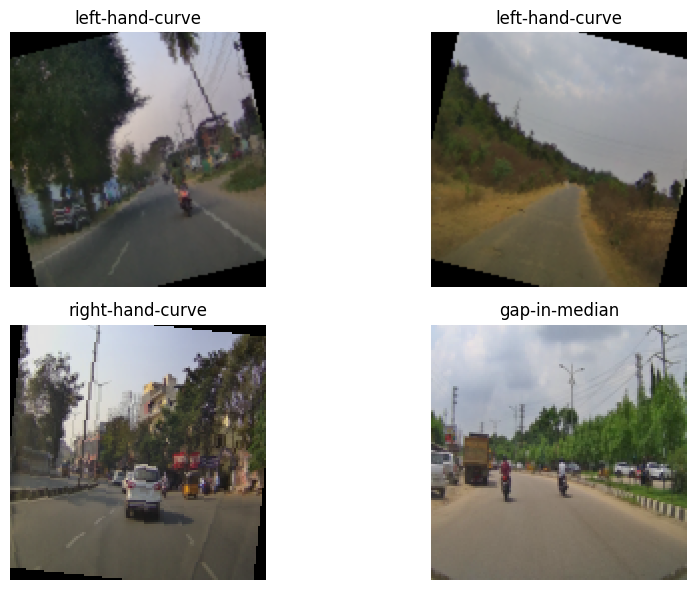

In [ ]:
mean_tensor = torch.tensor(mean).view(1,1,3)
std_tensor  = torch.tensor(std).view(1,1,3)

plt.figure(figsize=(10,6))

for i in range(4):
    img = images[i].permute(1,2,0).cpu()
    img = img * std_tensor + mean_tensor
    img = torch.clamp(img, 0, 1)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(full_dataset.classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Phase 3**

In [ ]:
class TrafficSignCNN(nn.Module):

    def __init__(self, num_classes=num_classes):
        super(TrafficSignCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 32 * 32, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TrafficSignCNN(num_classes=num_classes)
model = model.to(device)

print(model)

TrafficSignCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Phase 4

In [ ]:
num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [ ]:
for epoch in range(num_epochs):

    # -------- TRAINING --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    # -------- VALIDATION --------
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}% "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

In [ ]:
_, predicted = torch.max(outputs.data, 1)

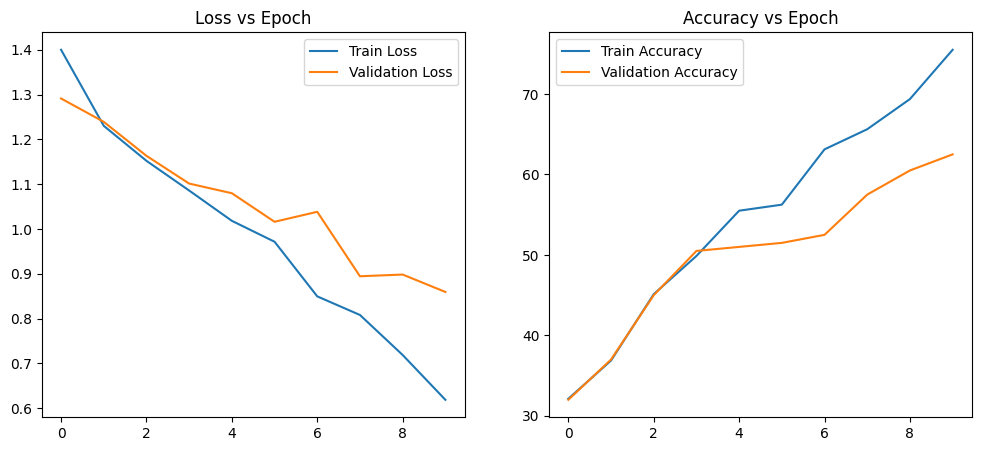

In [ ]:
model.eval()
with torch.no_grad():
  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.plot(train_losses, label="Train Loss")
  plt.plot(val_losses, label="Validation Loss")
  plt.legend()
  plt.title("Loss vs Epoch")

  plt.subplot(1,2,2)
  plt.plot(train_accuracies, label="Train Accuracy")
  plt.plot(val_accuracies, label="Validation Accuracy")
  plt.legend()
  plt.title("Accuracy vs Epoch")

  plt.show()

# Phase 5

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

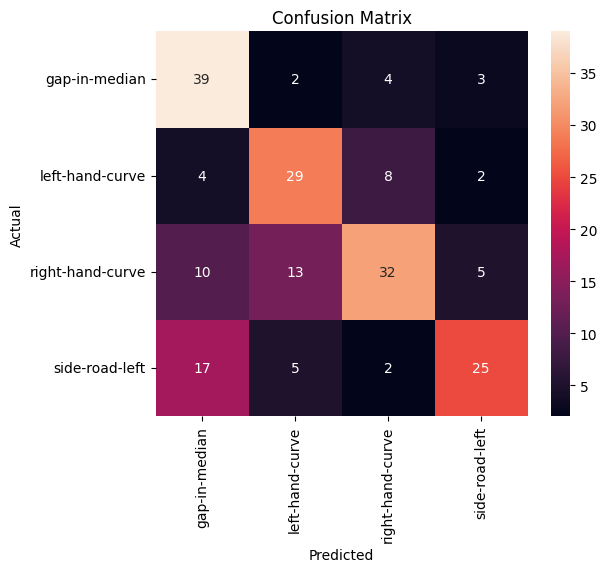

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(all_labels,
                            all_preds,
                            target_names=full_dataset.classes))

                  precision    recall  f1-score   support

   gap-in-median       0.56      0.81      0.66        48
 left-hand-curve       0.59      0.67      0.63        43
right-hand-curve       0.70      0.53      0.60        60
  side-road-left       0.71      0.51      0.60        49

        accuracy                           0.62       200
       macro avg       0.64      0.63      0.62       200
    weighted avg       0.64      0.62      0.62       200

